In [66]:
print("Hi")

Hi


In [67]:
import math 

In [85]:
class Value:
    def __init__(self,data,_children = (),_op = '',label = ''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self,other):
        out = Value(self.data + other.data,(self,other),'+')

        def _backward():
            self.grad = 1 * out.grad
            other.grad = 1 * out.grad
        out._backward = _backward

        return out

    def __mul__(self,other):
        out = Value(self.data * other.data,(self,other),'*')

        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward

        return out

    def __sub__(self,other):
        out = Value(self.data - other.data,(self,other),"-")
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t,(self,),"tanh")

        def _backward():
            self.grad = (1- t**2)* out.grad
        out._backward = _backward
        
        return out

a = Value(2.0,label='a')
b = Value(3.0,label = 'b')
a,b
c = Value(-10.0,label = 'c')
# a.__add__(b)
k = a*b ; k.label = 'k'
d = k + c ; d.label = 'd'
f = Value(-2.0,label = 'f')
L = d*f; L.label = "L"
print(L)
print(L._prev)
print(L._op)


Value(data=8.0)
{Value(data=-4.0), Value(data=-2.0)}
*


In [86]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

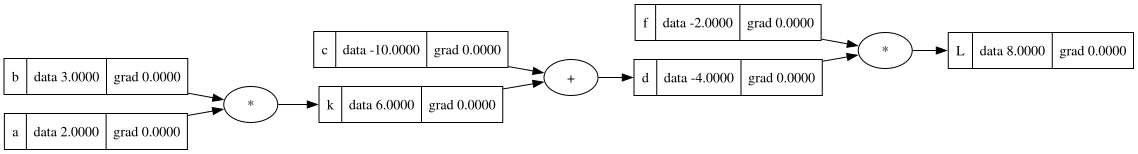

In [70]:
draw_dot(L)

differentiating \
L = f*d \
dL/dd = f \
dL/df = d \
 
dL/dd = -2 \
dL/df = -4

In [71]:
L.grad = 1.0
f.grad = -4
d.grad = -2.0

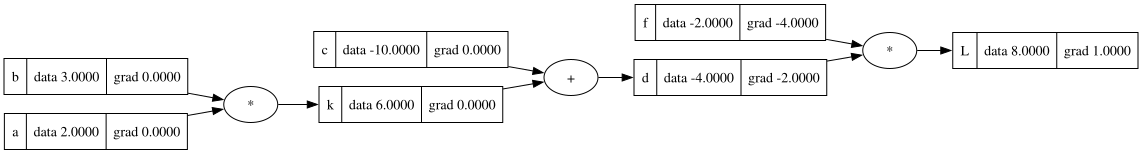

In [72]:
draw_dot(L)

Now we want to obtain : - \
\
dL/dc = ? \
dL/dK = ? \
\
We Know : \
\
dL/dc = (dL/dd)*(dd/dc)  \
\
d = k+c \
L = f*d \
dd/dc = 1 \
dd/dk = 1 \
dL/dd = -2 

\
dL/dc = -2 * 1 = -2 \
dL/dk = -2 * 1 = -2 

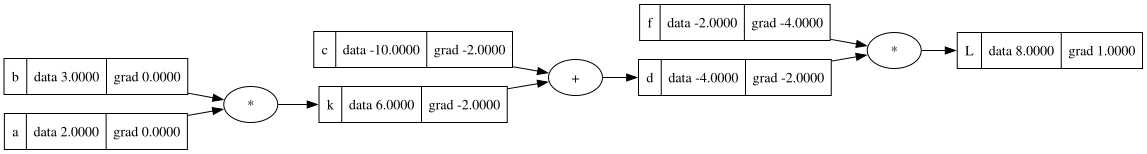

In [73]:
c.grad = -2
k.grad = -2

draw_dot(L)

Now we want to obtain : - \
\
dL/da = ? \
dL/db = ? \
\
We Know : \
\
dL/da = (dL/dd)(dd/dc)*(dc/da)  \
dL/db = (dL/dd)(dd/dc)*(dc/db)  \
\
k = a*b \
dc/da = b \
dd/db = a \

\
dL/da= 3 * 1 * -2  = -6 \
dL/db= 2 * 1 * -2  = -4

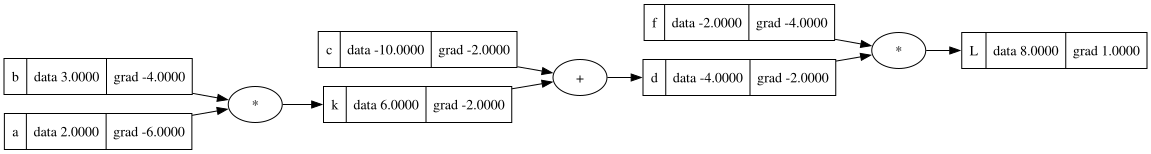

In [74]:
a.grad = -6
b.grad = -4

draw_dot(L)

In [75]:
def lol():
    h = 0.001
    a = Value(2.0,label='a')
    b = Value(3.0,label = 'b')
    c = Value(-10.0,label = 'c')
    k = a*b ; k.label = 'k'
    d = k + c ; d.label = 'd'
    f = Value(-2.0,label = 'f')
    L = d*f; L.label = "L"
    L1 = L.data


    a = Value(2.0,label='a')
    # a.data +=h
    b = Value(3.0,label = 'b')
    b.data +=h

    c = Value(-10.0,label = 'c')
    # c.data += h
    k = a*b ; k.label = 'k'
    d = k + c ; d.label = 'd'
    # d.data +=h
    f = Value(-2.0,label = 'f')
    # f.data +=h
    L = d*f; L.label = "L"
    L2 = L.data

    print((L2-L1)/h)

lol()

-3.9999999999995595


**Make a small neural network:-**

z = wx+b \

activation(z)

Value(data=0.9836748576936802)


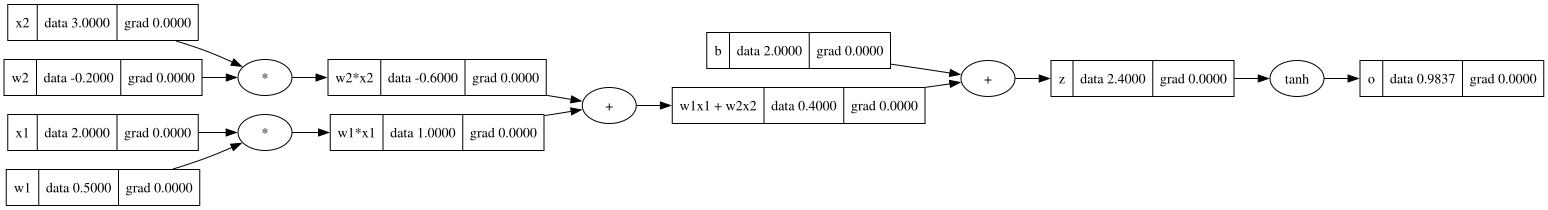

In [87]:
x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")

w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
z = W + b ; z.label = "z"
o = z.tanh(); o.label = "o"
print(o)
draw_dot(o)

do/dz = 1-(tanh)^2

0.032383774341317895


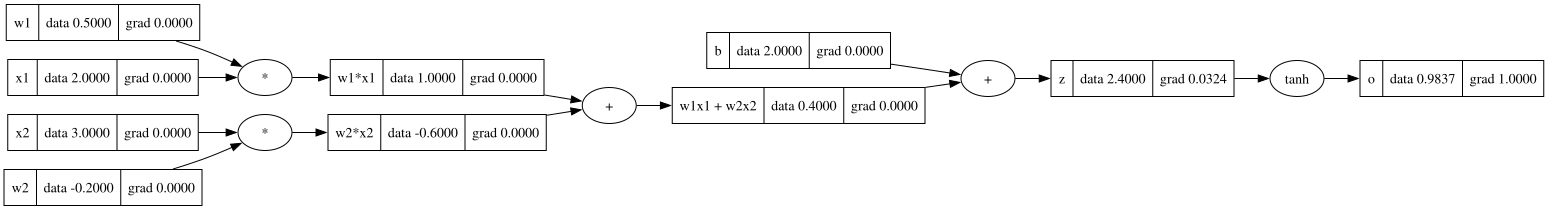

In [77]:
o.grad = 1.0
z.grad = 1 - (z.tanh().data)**2
print(z.grad)
draw_dot(o)

do/db = dz/db * do/dz   \
do/dW = dz/dW * do/dz   


do/db = do/dz = 1-(tanh(z))^2 = 0.0324

dz/db = ?
dz/dW = ?

z = Wx+b   \
dz/dW = dz/db = 1

do/db = 1 * 0.0324 = 0.0324  \
do/dW = 1 * 0.0324 = 0.0324


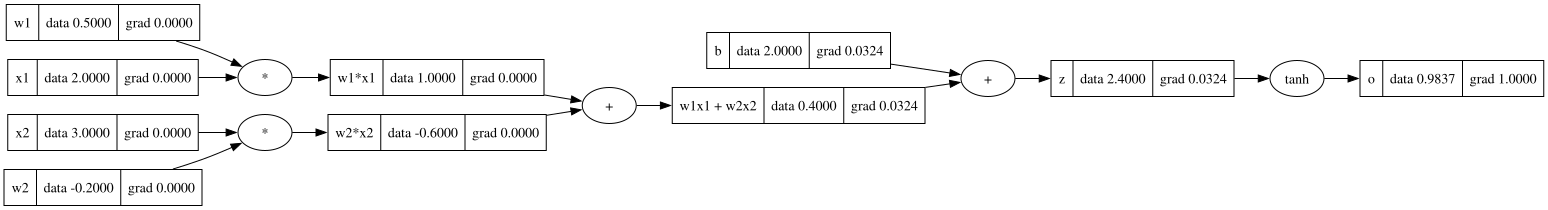

In [78]:
W.grad = 0.0324
b.grad = 0.0324
draw_dot(o)

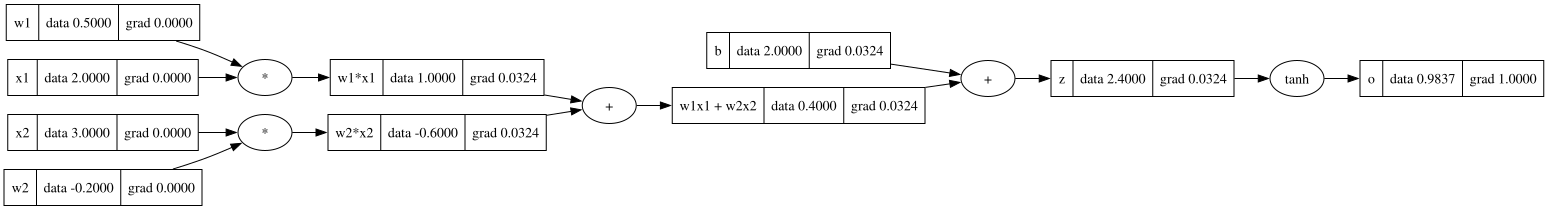

In [79]:
w1x1.grad = 0.0324
w2x2.grad = 0.0324
draw_dot(o)

0.0648


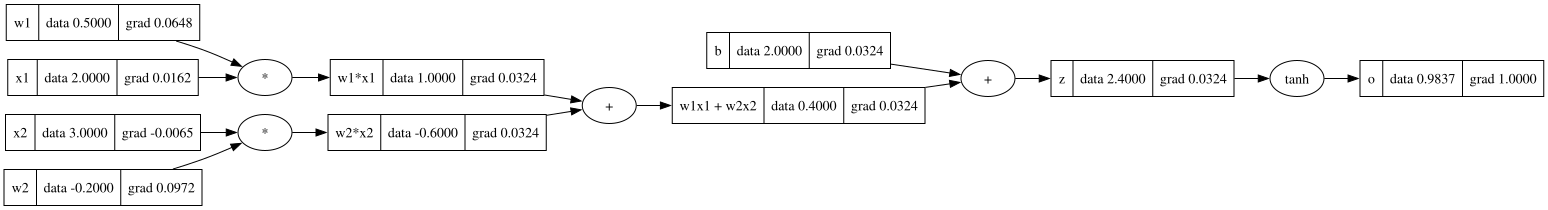

In [80]:
w1.grad = (x1.data) * (w1x1.grad)
print(w1.grad)
x1.grad = (w1.data) * (w1x1.grad)
w2.grad = (x2.data) * (w2x2.grad)
x2.grad = (w2.data) * (w2x2.grad)
draw_dot(o)

In [84]:
h = 0.001
x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")
w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
z = W + b ; z.label = "z"
o = z.tanh(); o.label = "o"
L1 = o.data
print(L1)


x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")

w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")
w1.data +=h

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
# b.data += h
z = W + b ; z.label = "z"
# z.data += h
o = z.tanh(); o.label = "o"

L2 = o.data
print(L2)
print((L2 - L1)/h)

0.9836748576936802
0.9837394979861149
0.06464029243469227


### Auto mate Backward Pass:-

Value(data=0.9836748576936802)


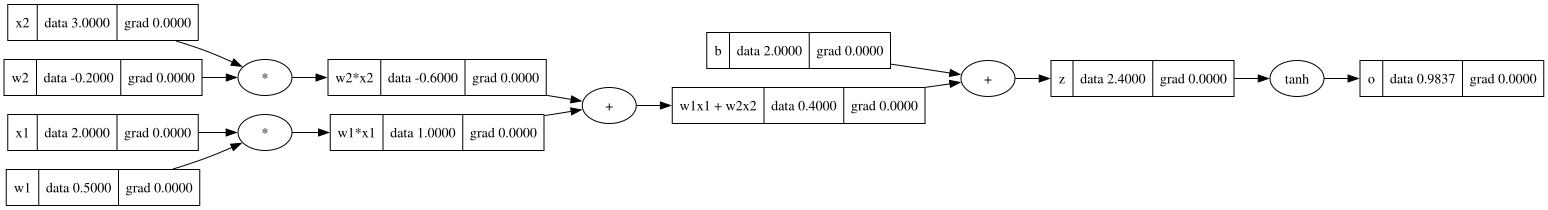

In [88]:
x1 = Value(2.0,label="x1")
x2 = Value(3.0,label="x2")

w1 = Value(0.5,label = "w1")
w2 = Value(-0.2,label = "w2")

b = Value(2.0,label = "b")

w1x1 = w1*x1 ;w1x1.label = "w1*x1"
w2x2 = w2*x2 ;w2x2.label = "w2*x2"

W = w1x1 + w2x2 ; W.label = "w1x1 + w2x2"
z = W + b ; z.label = "z"
o = z.tanh(); o.label = "o"
print(o)
draw_dot(o)

In [92]:
o.grad = 1.0

In [94]:
o._backward()

In [96]:
z._backward()

In [98]:
W._backward()

In [100]:
w2x2._backward()

In [102]:
w1x1._backward()

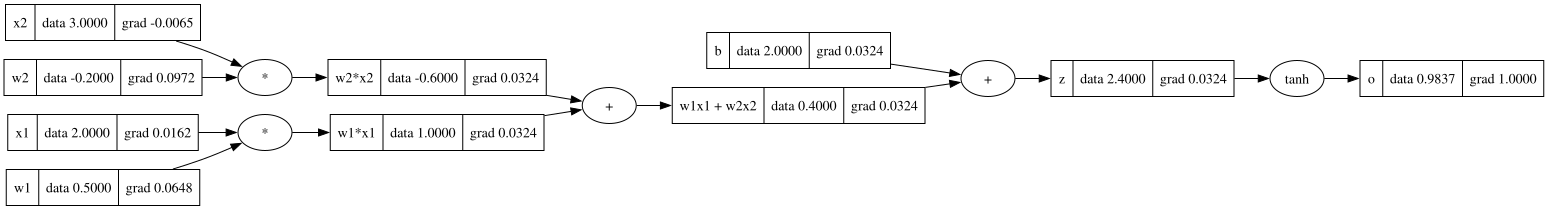

In [103]:

draw_dot(o)